In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator
import torch as th
import pandas as pd

In [2]:
# Updated function
def plot_entropy(
    groups,
    cosine_similarity_avg,
    cosine_similarity_avg_std,
    cosine_similarity_ens,
    normalized_entropy_avg,
    normalized_entropy_avg_std,
    normalized_entropy_ens,
    cosine_range,
    normalized_entropy_range,
    title,
    fontsize_scale=1.0,
    output_fp=None
):
    num_groups = len(groups)
    x = np.linspace(0, (num_groups - 1)/2, num_groups)  # Spread groups evenly along the x-axis

    # Calculate % difference
    cosine_diff = [(e - a) / a * 100 for a, e in zip(cosine_similarity_avg, cosine_similarity_ens)]
    entropy_diff = [(e - a) / a * 100 for a, e in zip(normalized_entropy_avg, normalized_entropy_ens)]

    # Bar settings
    width = 0.15  # Make bars thinner

    # Create subplots
    # fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, gridspec_kw={'height_ratios': [1, 1]})
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=False, gridspec_kw={'height_ratios': [1, 1]})

    # Top plot: Cosine Similarity
    ax1.bar(x - width / 2, cosine_similarity_avg, width, yerr=cosine_similarity_avg_std, label='Individual', color='#aec7e8', edgecolor='black')
    ax1.bar(x + width / 2, cosine_similarity_ens, width, label='Ensemble', color='#1f77b4', edgecolor='black')

    # Add % difference annotations above Ensemble bars
    for i, diff in enumerate(cosine_diff):
        ens_val = cosine_similarity_ens[i]
        ax1.text(
            x[i] + width / 2,
            ens_val + 0.005,  # Position slightly above the Ensemble bar
            f"{diff:+.1f}%",
            ha='center',
            va='bottom',
            fontsize=10*fontsize_scale,
            color='black',
            # weight='bold',
        )

    ax1.set_ylabel('Cosine Similarity', fontsize=12*fontsize_scale, labelpad=8*fontsize_scale)
    # ax1.set_title(title, fontsize=14*fontsize_scale)
    ax1.legend(fontsize=10*fontsize_scale, loc='upper left', facecolor='white', framealpha=0.9, ncol=2)
    ax1.set_ylim(*cosine_range)  # Adjust y-axis range for better fit
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    ax1.tick_params(axis='y', which='major', labelsize=10*fontsize_scale)

    ax1.set_xticks(x)
    ax1.set_xticklabels(groups, fontsize=10*fontsize_scale)
    ax1.yaxis.set_major_locator(MultipleLocator(0.1))

    # Bottom plot: Normalized Entropy
    ax2.bar(x - width / 2, normalized_entropy_avg, width, yerr=normalized_entropy_avg_std, label='Individual', color='#ff9896', edgecolor='black') #color='#ffbb78')
    ax2.bar(x + width / 2, normalized_entropy_ens, width, label='Ensemble', color='#d62728', edgecolor='black') #color='#ff7f0e')

    # Add % difference annotations above Ensemble bars
    for i, diff in enumerate(entropy_diff):
        ens_val = normalized_entropy_ens[i]
        ax2.text(
            x[i] + width / 2,
            ens_val + 0.005,  # Position slightly above the Ensemble bar
            f"{diff:+.1f}%",
            ha='center',
            va='bottom',
            fontsize=10*fontsize_scale,
            color='black',
            # weight='bold',
        )

    ax2.set_ylabel('Normalized Entropy', fontsize=12*fontsize_scale, labelpad=8*fontsize_scale)
    # ax2.set_xlabel('Ensemble Type', fontsize=12*fontsize_scale)
    ax2.legend(fontsize=10*fontsize_scale, loc='upper left', facecolor='white', framealpha=0.9, ncol=2)
    ax2.set_ylim(*normalized_entropy_range)  # Adjust y-axis range for better fit
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    ax2.tick_params(axis='y', which='major', labelsize=10*fontsize_scale)

    ax2.set_xticks(x)
    ax2.set_xticklabels(groups, fontsize=10*fontsize_scale)
    ax2.yaxis.set_major_locator(MultipleLocator(0.1))

    # Adjust layout
    # plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.tight_layout()

    # save figure
    if output_fp is not None:
        plt.savefig(output_fp, format="pdf", bbox_inches="tight")

    plt.show()


In [3]:
e_stats = th.load("../figs/frag_ann_exp/ensemble_stats.pkl")
ea_stats = th.load("../figs/frag_ann_exp/ensemble_agreement_stats_c.pkl")
ea_nb_stats = th.load("../figs/frag_ann_exp/ensemble_agreement_stats_nb_c.pkl")

In [4]:
e_stats["scaffold_d4_baseline"]

{'ind_cos_sim_bin_mean': 0.678451418876648,
 'ind_cos_sim_bin_std': 0.0013553170720115304,
 'ind_cos_hun_mean': 0.6540908813476562,
 'ind_cos_hun_std': 0.001654334249906242,
 'ens_cos_sim_bin_mean': 0.7074896693229675,
 'ens_cos_hun_mean': 0.6818397641181946,
 'ind_formula_node_ne_mean': 0.3985898494720459,
 'ind_formula_node_ne_std': 0.01013531256467104,
 'ind_nb_formula_node_ne_mean': 0.2997652590274811,
 'ind_nb_formula_node_ne_std': 0.010653376579284668,
 'ens_formula_node_ne_mean': 0.43165940046310425,
 'ens_nb_formula_node_ne_mean': 0.332570880651474}

In [5]:
def ensemble_stats_to_df(ensemble_stats_d, key_to_model):

    df = []
    for key, model in key_to_model.items():
        row = {}
        row["model"] = model
        for k, v in ensemble_stats_d[key].items():
            row[k] = v
        df.append(row)
    df = pd.DataFrame(df)
    return df

In [6]:
key_to_model = {
    "scaffold_d4_baseline": "Baseline",
    "scaffold_d4_low": "Low",
    "scaffold_d4_high": "High",
    "scaffold_d4_mix": "Mix",
}

e_df = ensemble_stats_to_df(e_stats, key_to_model)

[0.65409088 0.65261352 0.65433735 0.65411913]
[0.68183976 0.68095773 0.68166453 0.68190378]
[0.39858985 0.33735847 0.48034212 0.40573174]
[0.4316594  0.37065902 0.51696181 0.45205981]


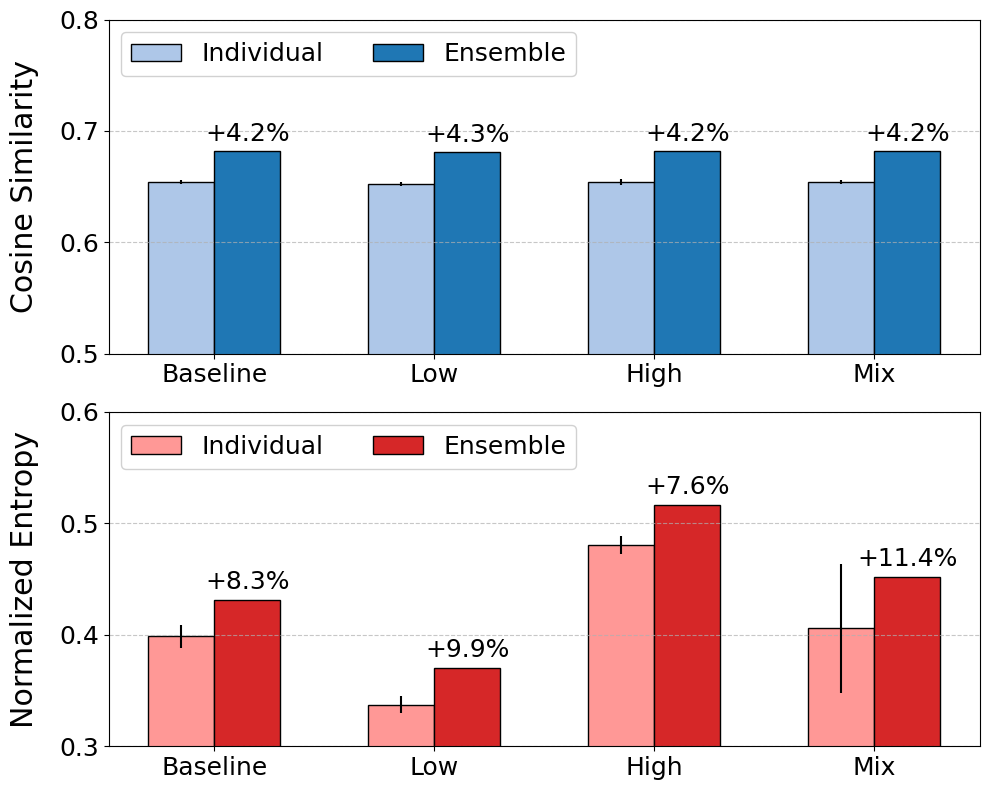

In [7]:
cosine_range = [0.5,0.8]
normalized_entropy_range = [0.3,0.6]
title = None #"FraGNNet D4 Scaffold Ensemble Results (Iso)"

print(e_df["ind_cos_hun_mean"].values)
print(e_df["ens_cos_hun_mean"].values)
print(e_df["ind_formula_node_ne_mean"].values)
print(e_df["ens_formula_node_ne_mean"].values)
plot_entropy(
    e_df["model"],
    e_df["ind_cos_hun_mean"],
    e_df["ind_cos_hun_std"],
    e_df["ens_cos_hun_mean"],
    e_df["ind_formula_node_ne_mean"],
    e_df["ind_formula_node_ne_std"],
    e_df["ens_formula_node_ne_mean"],
    cosine_range,
    normalized_entropy_range,
    title=title,
    fontsize_scale=1.8,
    output_fp="../figs/frag_ann_exp/bar_scaffold_d4.pdf"
)

[0.65409088 0.65261352 0.65433735 0.65411913]
[0.68183976 0.68095773 0.68166453 0.68190378]
[0.39858985 0.33735847 0.48034212 0.40573174]
[0.4316594  0.37065902 0.51696181 0.45205981]


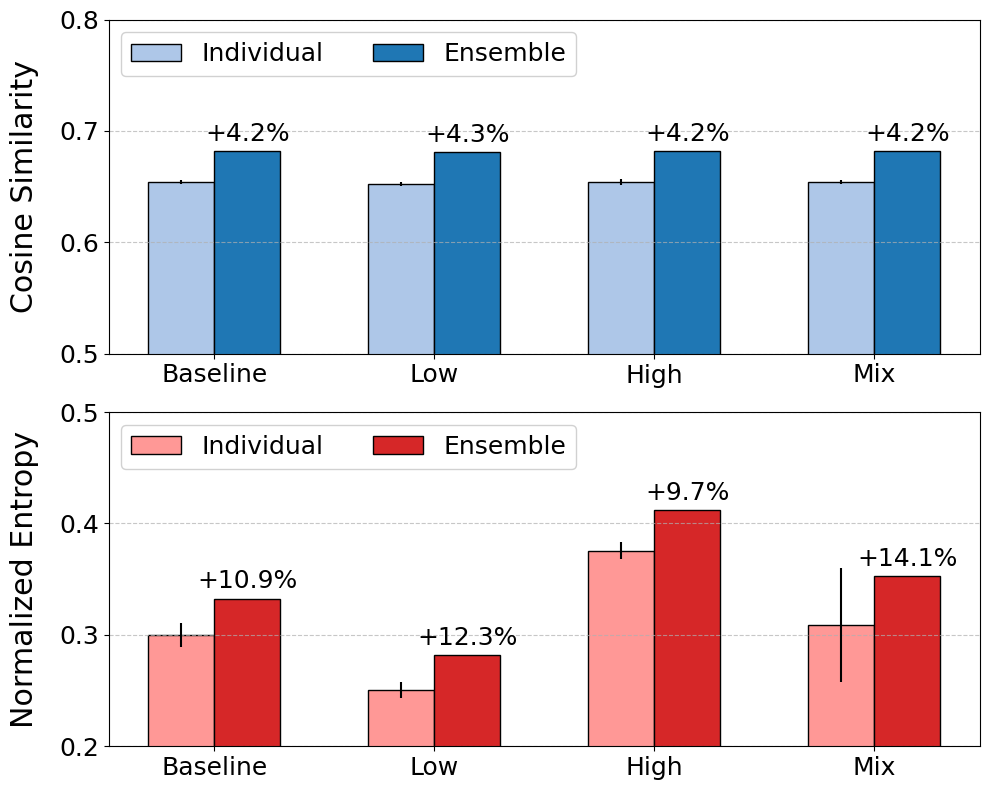

In [8]:
cosine_range = [0.5,0.8]
normalized_entropy_range = [0.2,0.5]
title = None #"FraGNNet D4 Scaffold Ensemble Results (Non-Iso)"

print(e_df["ind_cos_hun_mean"].values)
print(e_df["ens_cos_hun_mean"].values)
print(e_df["ind_formula_node_ne_mean"].values)
print(e_df["ens_formula_node_ne_mean"].values)
plot_entropy(
    e_df["model"],
    e_df["ind_cos_hun_mean"],
    e_df["ind_cos_hun_std"],
    e_df["ens_cos_hun_mean"],
    e_df["ind_nb_formula_node_ne_mean"],
    e_df["ind_nb_formula_node_ne_std"],
    e_df["ens_nb_formula_node_ne_mean"],
    cosine_range,
    normalized_entropy_range,
    title=title,
    fontsize_scale=1.8,
    output_fp="../figs/frag_ann_exp/bar_scaffold_d4_nb.pdf"
)

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.colors as mcolors

def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=100):
    new_cmap = mcolors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n))
    )
    return new_cmap

def plot_agreement_matrix(
    agreement_matrix, 
    model_labels=None, 
    title="Pairwise Agreement Matrix",
    fontsize_scale=1.0,
    convert_to_percent=False,
    cmap_str="Blues_r",
    cmap_input_range=(0.8, 1.0),
    cmap_output_range=(0.2, 0.7),
    output_fp=None
):
    """
    Plots a heatmap for the pairwise agreement matrix of n models.
    
    Parameters:
        agreement_matrix (np.ndarray): An n x n matrix representing agreement values between models.
        model_labels (list of str, optional): Labels for the models. Defaults to "Model 1", "Model 2", etc.
        title (str): Title of the plot.
    """
    n = agreement_matrix.shape[0]
    if model_labels is None:
        model_labels = [f"Model {i}" for i in range(1, n + 1)]
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # cmap = plt.cm.Blues  # Colormap for the heatmap
    cmap = plt.cm.get_cmap(cmap_str)  # Alternative colormap
    cmap = truncate_colormap(cmap,cmap_output_range[0],cmap_output_range[1])
    if convert_to_percent:
        agreement_matrix = agreement_matrix * 100
        cmap_input_range = (int(np.around(cmap_input_range[0]*100)), int(np.around(cmap_input_range[1]*100)))
    im = ax.imshow(agreement_matrix, cmap=cmap, vmin=cmap_input_range[0], vmax=cmap_input_range[1])

    # Set axis labels and ticks
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(model_labels, fontsize=12*fontsize_scale)
    ax.set_yticklabels(model_labels, fontsize=12*fontsize_scale)

    # Rotate x-axis labels if needed
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    # Add annotations
    min_val = np.min(agreement_matrix)
    max_val = np.max(agreement_matrix)
    for i in range(n):
        for j in range(n):
            val = agreement_matrix[i, j]
            if np.isnan(val):
                text = ""
                size_frac = 0.85
            else:
                if convert_to_percent:
                    text = f"{int(np.around(val))}%"
                else:
                    text = f"{np.around(val,decimals=2):.2f}"
                size_frac =  (0.85 + 0.15 * (val - min_val) / (max_val - min_val))
            ax.text(j, i, text, ha="center", va="center", color="black", fontsize=size_frac*12*fontsize_scale)

    # Add title
    if title is not None:
        ax.set_title(title, fontsize=12*fontsize_scale, pad=16*fontsize_scale)

    # Layout adjustments
    plt.tight_layout()
    
    # Save to file
    if output_fp is not None:
        plt.savefig(output_fp, format="pdf", bbox_inches="tight")

    plt.show()


/tmp/ipykernel_26590/346135668.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_str)  # Alternative colormap


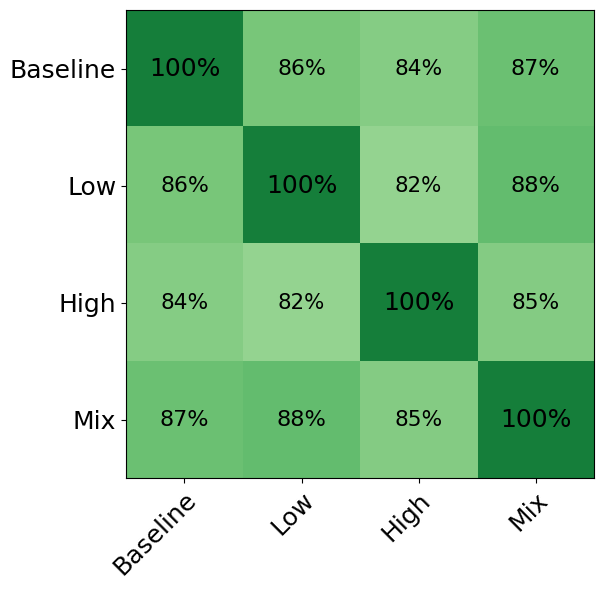

0.7597454190254211


In [10]:
# Example usage:

compare_mat = ea_stats["compare_mat_spec_1"].numpy()
compare_all = ea_stats["compare_all_spec_1"].item()
plot_agreement_matrix(
    compare_mat,
    model_labels=["Baseline", "Low", "High", "Mix"],
    title=None,
    fontsize_scale=1.5,
    convert_to_percent=True,
    cmap_str="Greens",
    cmap_input_range=(compare_mat.min(), 1.0),
    cmap_output_range=(0.4, 0.8),
    output_fp="../figs/frag_ann_exp/mat_scaffold_d4.pdf"
)
print(compare_all)

/tmp/ipykernel_26590/346135668.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_str)  # Alternative colormap


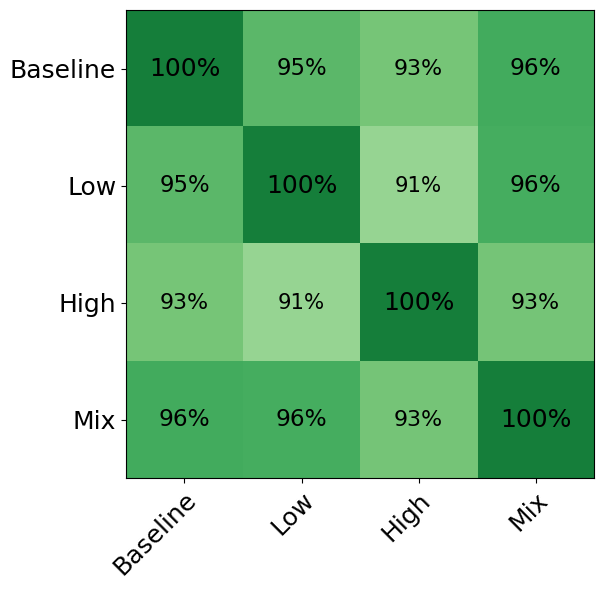

0.8933804035186768


In [11]:
# Example usage:

compare_mat = ea_nb_stats["compare_mat_spec_1"].numpy()
compare_all = ea_nb_stats["compare_all_spec_1"].item()
plot_agreement_matrix(
    compare_mat,
    model_labels=["Baseline", "Low", "High", "Mix"],
    title=None,
    fontsize_scale=1.5,
    convert_to_percent=True,
    cmap_str="Greens",
    cmap_input_range=(compare_mat.min(), 1.0),
    cmap_output_range=(0.4, 0.8),
    output_fp="../figs/frag_ann_exp/mat_scaffold_d4_nb.pdf"
)
print(compare_all)